# **Representasi Data dan Feature Engineering**
Catatan ini menyajikan implementasi praktis dan landasan teoretis mengenai representasi data dan feature engineering berdasarkan Bab 4 dari buku "Introduction to Machine Learning with Python" (Müller & Guido).

Performa model machine learning tidak hanya bergantung pada pemilihan algoritma yang tepat, tetapi sangat dipengaruhi oleh bagaimana data direpresentasikan. Tahapan ini berfokus pada transformasi fitur mentah menjadi bentuk yang lebih informatif dan relevan agar pola dalam data lebih mudah dipelajari oleh algoritma.

## **Tujuan Pembelajaran**
Memahami Feature Engineering: Mengetahui alasan esensial mengapa transformasi fitur berdampak langsung pada performa model.

Klasifikasi Fitur: Mampu membedakan representasi fitur kontinu dan kategorikal (kapan suatu angka bermakna kuantitatif atau sekadar label).

Transformasi Data: Menerapkan teknik One-Hot Encoding, Binning, Interaction Features, Polynomial Features, dan Nonlinear Transformations.

Evaluasi Dampak: Membandingkan bagaimana transformasi tertentu dapat meningkatkan performa pada satu model (seperti Linear Regression) namun belum tentu berdampak pada model lain (seperti Random Forest).

# **Bagian 1: Persiapan Lingkungan Kerja (Environment Setup)**
Modul ini menggunakan dataset sintetis dan dataset bawaan dari scikit-learn agar eksperimen dapat direproduksi secara mandiri tanpa memerlukan berkas eksternal.

In [26]:
# Memuat pustaka komputasi, manipulasi data, dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat modul scikit-learn untuk preprocessing dan pemodelan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score

# Konfigurasi parameter dasar
np.random.seed(42)
pd.set_option("display.max_columns", 100)

# **Bagian 2: Variabel Kategorikal & One-Hot Encoding**
Variabel kategorikal adalah fitur yang nilainya merepresentasikan kelompok atau label, bukan besaran numerik. Ciri utamanya adalah tidak memiliki jarak matematis yang terukur (contoh: kategori pekerjaan "PNS" dan "Swasta" tidak dapat dikurangi atau ditambahkan). Karena sebagian besar algoritma machine learning beroperasi menggunakan persamaan matematis, kategori ini wajib dikonversi menjadi representasi numerik.

Kesalahan fatal yang sering terjadi adalah memberikan label angka berurutan (0, 1, 2) pada kategori nominal. Hal ini akan mengelabui model untuk berasumsi bahwa kategori bernilai 2 lebih "besar" dari kategori bernilai 0. Solusi standar untuk masalah ini adalah One-Hot Encoding, di mana setiap kategori unik diubah menjadi kolom biner terpisah (bernilai 0 atau 1).

In [27]:
# 1. Definisi Dataset Kategorikal Sederhana
data = pd.DataFrame({
    "age": [39, 50, 38, 53, 28, 37, 49, 52, 31, 42],
    "workclass": ["State-gov", "Self-emp", "Private", "Private", "Private",
                  "Private", "Private", "Self-emp", "Private", "Private"],
    "education": ["Bachelors", "Bachelors", "HS-grad", "11th", "Bachelors",
                  "Masters", "9th", "HS-grad", "Masters", "Bachelors"],
    "gender": ["Male", "Male", "Male", "Male", "Female",
               "Female", "Female", "Male", "Female", "Male"],
    "hours_per_week": [40, 13, 40, 40, 40, 40, 16, 45, 50, 40],
    "income": ["<=50K", "<=50K", "<=50K", "<=50K", "<=50K",
               "<=50K", "<=50K", ">50K", ">50K", ">50K"]
})

# 2. Implementasi One-Hot Encoding menggunakan Pandas
data_encoded = pd.get_dummies(data, columns=["workclass", "education", "gender"], drop_first=False)

# Memisahkan matriks fitur (X) dan vektor target biner (y)
X = data_encoded.drop(columns=["income"])
y = (data_encoded["income"] == ">50K").astype(int)

print(f"Dimensi matriks fitur (X) setelah One-Hot Encoding: {X.shape}")

Dimensi matriks fitur (X) setelah One-Hot Encoding: (10, 12)


# **Penerapan dalam Pipeline:**
Untuk mencegah kebocoran informasi (data leakage) antara data latih dan data uji, encoding sebaiknya diintegrasikan ke dalam objek Pipeline.

In [28]:
# 3. Implementasi One-Hot Encoding menggunakan Scikit-Learn Pipeline
X_raw = data.drop(columns=["income"])
y_raw = (data["income"] == ">50K").astype(int)

numeric_features = ["age", "hours_per_week"]
categorical_features = ["workclass", "education", "gender"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_raw, y_raw)
print("Akurasi Model pada data latih:", accuracy_score(y_raw, model.predict(X_raw)))

Akurasi Model pada data latih: 0.9


# **Bagian 3: Kategori Numerik (Numeric Categories)**
Tidak semua angka merepresentasikan besaran kuantitatif yang kontinu. Angka yang bertindak sebagai ID atau kode klasifikasi (misal: 0 = Merah, 1 = Biru, 2 = Hijau) wajib diperlakukan sebagai variabel kategorikal. Sebelum dilakukan One-Hot Encoding, tipe data dari kolom tersebut harus dikonversi menjadi format string atau category agar fungsi tidak memprosesnya sebagai nilai matematika.

In [29]:
# Demonstrasi penanganan kategori berbasis angka
demo_df = pd.DataFrame({
    "Kode_Pekerjaan": [0, 1, 2, 1, 0],  # Angka ini adalah label kategori, bukan nilai kontinu
    "Jam_Kerja": [40, 35, 45, 20, 50]
})

# Konversi tipe data ke string sebelum di-encode
encoded_demo = pd.get_dummies(demo_df.astype({"Kode_Pekerjaan": str}), columns=["Kode_Pekerjaan"])
display(encoded_demo)

,Jam_Kerja,Kode_Pekerjaan_0,Kode_Pekerjaan_1,Kode_Pekerjaan_2
0,40,True,False,False
1,35,False,True,False
2,45,False,False,True
3,20,False,True,False
4,50,True,False,False


# **Bagian 4: Binning dan Discretization**
Binning adalah teknik mempartisi rentang nilai fitur kontinu menjadi sekumpulan interval tetap. Proses ini sangat bermanfaat untuk algoritma linear, mengubah hubungan yang tadinya berupa satu garis lurus monoton menjadi fungsi tangga (step function) yang fleksibel

In [30]:
# Simulasi Dataset 1D
rng = np.random.RandomState(42)
X_wave = rng.uniform(-3, 3, size=(120, 1))
y_wave = np.sin(X_wave[:, 0]) + 0.3 * X_wave[:, 0] + rng.normal(scale=0.25, size=120)

# Implementasi Binning dan Transformasi ke format One-Hot
bin_edges = np.linspace(-3, 3, 11)
which_bin = np.digitize(X_wave[:, 0], bins=bin_edges)

encoder = OneHotEncoder(sparse_output=False)
X_binned = encoder.fit_transform(which_bin.reshape(-1, 1))

print(f"Bentuk fitur asli kontinu: {X_wave.shape}")
print(f"Bentuk fitur diskrit (binned): {X_binned.shape}")

Bentuk fitur asli kontinu: (120, 1)
Bentuk fitur diskrit (binned): (120, 10)


# **Bagian 5: Fitur Interaksi (Interaction Features)**
Fitur interaksi dibangun dengan menggabungkan dua atau lebih fitur yang ada, seringkali melalui perkalian silang. Pada kasus binning di atas, Linear Regression hanya mampu menebak satu nilai konstan (rata-rata) pada setiap rentang interval. Dengan menambahkan interaksi antara nilai kontinu asli dengan setiap interval (bin), model linear dapat memodelkan kemiringan (slope) garis yang berbeda-beda untuk setiap interval secara independen.

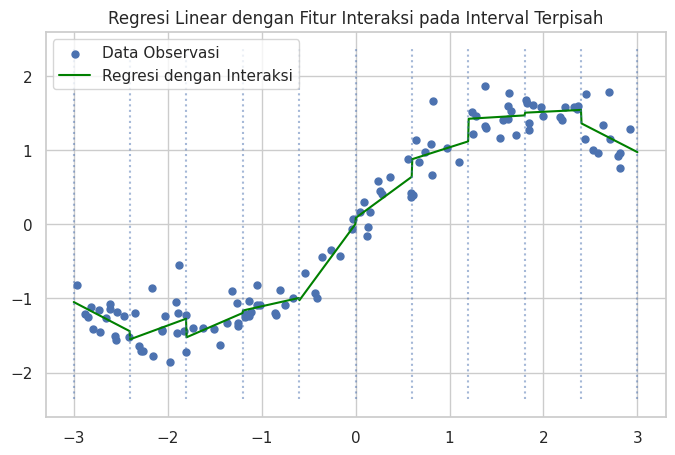

In [31]:
# Membuat fitur interaksi antara interval bin dan nilai kontinu asli
X_interaction = np.hstack([X_binned, X_wave * X_binned])

line = np.linspace(-3, 3, 1000).reshape(-1, 1)
line_bin = np.clip(np.digitize(line[:, 0], bins=bin_edges), 1, len(bin_edges) - 1)
line_binned = encoder.transform(line_bin.reshape(-1, 1))
line_interaction = np.hstack([line_binned, line * line_binned])

lin_reg_interaction = LinearRegression().fit(X_interaction, y_wave)

plt.figure(figsize=(8, 5))
plt.scatter(X_wave[:, 0], y_wave, s=25, label="Data Observasi")
plt.plot(line[:, 0], lin_reg_interaction.predict(line_interaction), color='green', label="Regresi dengan Interaksi")
plt.vlines(bin_edges, ymin=y_wave.min()-0.5, ymax=y_wave.max()+0.5, linestyles="dotted", alpha=0.5)
plt.title("Regresi Linear dengan Fitur Interaksi pada Interval Terpisah")
plt.legend()
plt.show()

# **Bagian 6: Fitur Polinomial (Polynomial Features)**
Fitur polinomial adalah teknik ekspansi ruang fitur yang dilakukan dengan menambahkan pangkat komposit dari fitur yang ada (misal: $x^2$, $x^3$). Meskipun transformasi ini menempatkan data pada fungsi eksponensial, secara matematis koefisien pembobotnya tetap beroperasi sebagai sistem linear regresi biasa.

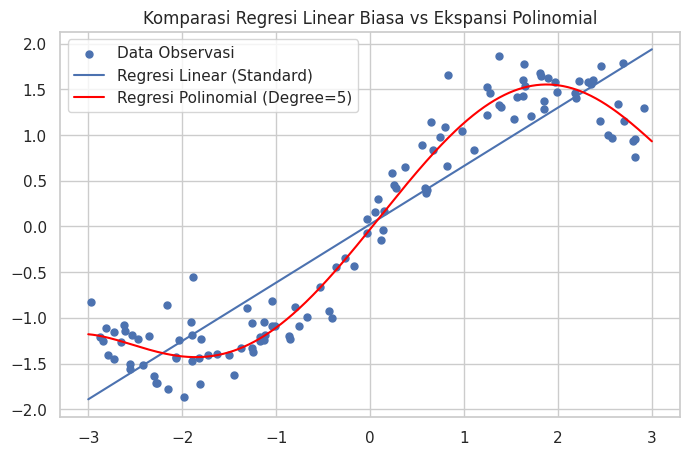

In [32]:
# Simulasi Regresi Polinomial derajat 5
poly_model = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(X_wave, y_wave)
lin_reg = LinearRegression().fit(X_wave, y_wave)

plt.figure(figsize=(8, 5))
plt.scatter(X_wave[:, 0], y_wave, s=25, label="Data Observasi")
plt.plot(line[:, 0], lin_reg.predict(line), label="Regresi Linear (Standard)")
plt.plot(line[:, 0], poly_model.predict(line), color='red', label="Regresi Polinomial (Degree=5)")
plt.title("Komparasi Regresi Linear Biasa vs Ekspansi Polinomial")
plt.legend()
plt.show()

# **Bagian 7: Transformasi Non-Linear (Log Transform)**

Transformasi logaritmik $\log(1+x)$ secara ekstensif digunakan untuk menormalisasi data kontinu yang memiliki distribusi probabilitas sangat menceng ke kanan (right-skewed distribution). Dataset hitungan alami (jumlah penjualan, durasi klik) umumnya didominasi oleh sekumpulan angka kecil dengan beberapa segelintir data bernilai masif yang bertindak sebagai outliers.

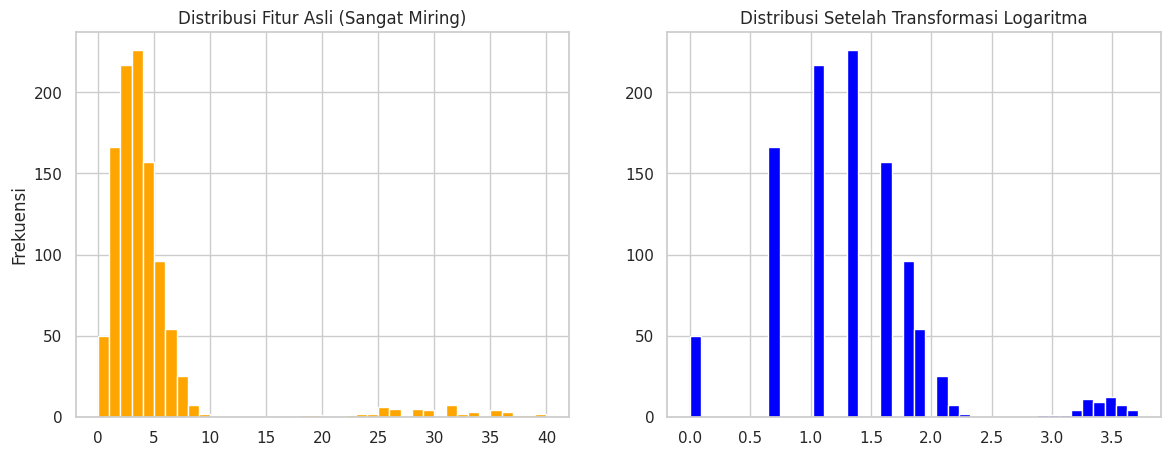

In [33]:
# Membuat sampel distribusi sangat miring (Poisson Distribution)
rng = np.random.RandomState(42)
count_data = rng.poisson(lam=3, size=1000)
count_data = np.concatenate([count_data, rng.poisson(lam=30, size=50)])

# Transformasi stabilitas numerik menggunakan log(1 + x)
log_count_data = np.log1p(count_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(count_data, bins=40, color='orange')
axes[0].set_title("Distribusi Fitur Asli (Sangat Miring)")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(log_count_data, bins=40, color='blue')
axes[1].set_title("Distribusi Setelah Transformasi Logaritma")
plt.show()